<a href="https://colab.research.google.com/github/EyanaCooper/my-tcs-earthquake-project/blob/main/earthquake_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *

In [2]:
url = 'https://github.com/EyanaCooper/my-tcs-earthquake-project/raw/refs/heads/main/earthquakes.csv'

df = pd.read_csv(url)

df.head(30)

,time,latitude,longitude,depth,mag,magType,net,id,place,type
0,2017-02-21 01:41:11.800000+00:00,-20.3521,-177.7955,512.760,4.40,mb,us,us1000860s,"283 km WNW of Haveluloto, Tonga",earthquake
1,2020-06-10 12:58:33.535000+00:00,69.3927,-143.9529,12.500,3.10,ml,ak,ak0207g4jxgn,"83 km S of Kaktovik, Alaska",earthquake
2,2020-11-29 01:02:57.577000+00:00,3.7184,126.3073,122.480,4.20,mb,us,us7000cmmz,"208 km SSE of Sarangani, Philippines",earthquake
3,2015-12-11 22:07:37.420000+00:00,-19.7988,-69.2959,107.450,4.30,mb,us,us20004hcx,"100 km ENE of Iquique, Chile",earthquake
4,2023-07-23 12:33:29.354000+00:00,-8.6271,111.1186,96.623,5.10,mb,us,us7000khss,"Java, Indonesia",earthquake
5,2020-04-29 17:47:07.930000+00:00,4.6331,127.0070,61.800,4.80,mb,us,us60009eug,"191 km ESE of Sarangani, Philippines",earthquake
6,2022-03-02 17:22:03.641000+00:00,-17.8077,167.5175,10.000,4.40,mb,us,us6000h2tn,"84 km W of Port-Vila, Vanuatu",earthquake
7,2022-01-14 06:34:22.004000+00:00,0.5443,92.2519,10.000,4.40,mb,us,us7000gdxx,off the west coast of northern Sumatra,earthquake
8,2015-12-05 12:12:01.160000+00:00,3.3004,127.2654,68.010,4.10,mb,us,us20004fsc,"192 km NNW of Tobelo, Indonesia",earthquake
9,2022-08-30 18:38:10.849000+00:00,-31.1642,-178.9115,10.000,4.30,mb,us,us7000i60y,Kermadec Islands region,earthquake


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178752 entries, 0 to 178751
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       178752 non-null  object 
 1   latitude   178752 non-null  float64
 2   longitude  178752 non-null  float64
 3   depth      178752 non-null  float64
 4   mag        178752 non-null  float64
 5   magType    178751 non-null  object 
 6   net        178752 non-null  object 
 7   id         178752 non-null  object 
 8   place      178752 non-null  object 
 9   type       178752 non-null  object 
dtypes: float64(4), object(6)
memory usage: 13.6+ MB


Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'net', 'id',
       'place', 'type'],
      dtype='object')


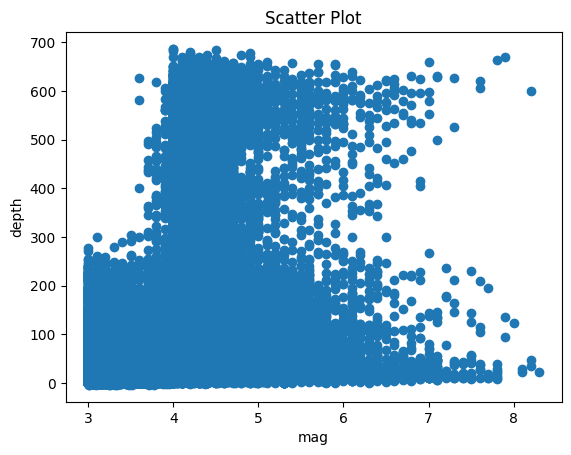

In [4]:
print(df.columns)
df = df.dropna(subset=["mag", "depth"])
plt.scatter(df["mag"], df["depth"])

plt.title("Scatter Plot")
plt.xlabel("mag")
plt.ylabel("depth")
df = df[df["mag"]>=5]
plt.show()

In [18]:
X= df[["depth"]]
y = df["mag"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, y_train)
y_pred = lin_reg_model.predict(X_test)
print("Linear Regression model")
print(f"MSE:{mean_squared_error(y_test, y_pred)}")
print("R2:",r2_score(y_test, y_pred))
print("Coefficients:", lin_reg_model.coef_)
print("Intercept:",lin_reg_model.intercept_)
print()


Linear Regression model
MSE:0.166402365110008
R2: 0.013108795764376846
Coefficients: [0.00042212]
Intercept: 5.315405407642992

